<a href="https://colab.research.google.com/github/shatlykgurdov/jupyter_notebooks/blob/main/ML_Finance_GWP2_15855_Combined_Clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MScFE 632: Machine Learning in Finance
## Group Work Project 2 — Group 15855

**Student A:** Shatlyk Gurdov — Issue 1: Optimizing Hyperparameters  
**Student B:** Yang Liu — Issue 2: Optimizing the Bias-Variance Trade-off  
**Student C:** Vasanth P — Issue 3: Applying Ensemble Learning—Bagging, Boosting, or Stacking  

> The three source notebooks are combined in Issue 1 → Issue 2 → Issue 3 order.  
> Duplicate imports were removed and centralized below. Existing source outputs are retained; run all cells from the top before final submission to refresh them in one execution sequence.


# Common Imports and Global Definitions

Run this cell first. Imports, reproducibility settings, display options, and the shared output directory are centralized here.


In [1]:
# ============================================================
# MScFE 632 — Machine Learning in Finance
# Group Work Project 2 | Group 15855
# Common Imports and Global Definitions
# ============================================================

from pathlib import Path
import json
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.base import clone
from sklearn.datasets import make_classification
from sklearn.decomposition import PCA
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier,
)
from sklearn.linear_model import Lasso, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    TimeSeriesSplit,
    KFold,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Shared output directory
OUTPUT_DIR = Path("gwp2_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Display settings
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams["figure.figsize"] = (8, 4.8)
plt.rcParams["axes.grid"] = True

print("Common setup completed. Run Issue 1, Issue 2, and Issue 3 in order.")


Common setup completed. Run Issue 1, Issue 2, and Issue 3 in order.


# MScFE 632 Machine Learning in Finance - Group Work Project 2
## Student A - Issue 1: Optimizing Hyperparameters

**Author:** Shatlyk Gurdov  
**Reviewer:** Yang Liu  
**Group:** 15855

### Financial question
Can systematic hyperparameter optimization improve an explainable risk-warning model for identifying **high-volatility AAPL trading days one day in advance**, and can the optimized signal improve portfolio risk-adjusted performance?

This notebook directly addresses the three requirements of Issue 1:

1. **Which hyperparameters are relevant?**
2. **How are they optimized without using future information?**
3. **How do we know the selected configuration is preferable?**

The analysis uses a chronological test period and a risk-managed investment rule. The untuned benchmark is an unrestricted classification tree. The optimized specification combines standardized financial indicators, principal components, and a pruned classification tree.

## Question 1 - Data, target, and candidate hyperparameters

The target is a next-day high-volatility event. At date $t$, the next trading day is classified as high risk when

$$
|r_{t+1}| > Q_{0.75}\left(|r_{t-251}|,\ldots,|r_t|\right),
$$

where the threshold is the rolling 75th percentile of the previous 252 absolute daily returns. The threshold therefore uses only information available at the prediction date.

The candidate hyperparameters are:

- the number of retained principal components;
- split criterion;
- maximum tree depth;
- minimum observations required to split a node;
- minimum observations in a terminal node;
- cost-complexity pruning strength; and
- class weighting.

The search objective is **balanced accuracy**, which gives equal weight to correctly identifying normal-risk and high-risk observations.

In [2]:
# Load the historical AAPL data.
# The local file makes the notebook reproducible offline. If it is absent in Colab,
# the same public GitHub data file is downloaded automatically.
DATA_URL = (
    'https://raw.githubusercontent.com/FarhanAli97/'
    'Apple-AAPL-Stock-Data-1980-to-December-2024/'
    'refs/heads/main/Apple%20%28AAPL%29%20From%201980%20To%20Dec-2024.csv'
)

local_candidates = [
    Path('aapl_1980_2024.csv'),
    Path('/content/aapl_1980_2024.csv'),
    Path('/mnt/data/aapl_1980_2024.csv'),
]

for candidate in local_candidates:
    if candidate.exists():
        raw = pd.read_csv(candidate)
        data_source_used = str(candidate)
        break
else:
    raw = pd.read_csv(DATA_URL)
    data_source_used = DATA_URL

raw['Date'] = pd.to_datetime(raw['Date'].astype(str).str[:10])
raw = raw.set_index('Date').sort_index()
raw = raw.loc['2010-01-01':'2024-11-29', ['Open', 'High', 'Low', 'Close', 'Volume']].dropna()

print(f'Data source: {data_source_used}')
print(f'Raw observations: {len(raw):,}')
print(f'Date range: {raw.index.min().date()} to {raw.index.max().date()}')
raw.tail()

Data source: https://raw.githubusercontent.com/FarhanAli97/Apple-AAPL-Stock-Data-1980-to-December-2024/refs/heads/main/Apple%20%28AAPL%29%20From%201980%20To%20Dec-2024.csv
Raw observations: 3,753
Date range: 2010-01-04 to 2024-11-29


,Open,High,Low,Close,Volume
Date,,,,,
2024-11-22,228.0600,230.7200,228.0600,229.8700,38168300
2024-11-25,231.4600,233.2500,229.7400,232.8700,90152800
2024-11-26,233.3300,235.5700,233.3300,235.0600,45986200
2024-11-27,234.4700,235.6900,233.8100,234.9300,33498400
2024-11-29,234.8100,237.8100,233.9700,237.3300,28481400


In [3]:
# Build lagged financial indicators and the next-day high-volatility target.
def build_financial_dataset(price_data: pd.DataFrame) -> tuple[pd.DataFrame, list[str]]:
    close = price_data['Close']
    open_ = price_data['Open']
    high = price_data['High']
    low = price_data['Low']
    volume = price_data['Volume']

    ret = close.pct_change()
    abs_ret = ret.abs()
    df = pd.DataFrame(index=price_data.index)

    # Direction and momentum indicators
    df['return_1d'] = ret
    df['return_2d'] = close.pct_change(2)
    df['return_5d'] = close.pct_change(5)
    df['return_10d'] = close.pct_change(10)
    df['momentum_20d'] = close.pct_change(20)
    df['sma_5_20'] = close.rolling(5).mean() / close.rolling(20).mean() - 1
    df['sma_20_50'] = close.rolling(20).mean() / close.rolling(50).mean() - 1

    change = close.diff()
    gain = change.clip(lower=0).rolling(14).mean()
    loss = (-change.clip(upper=0)).rolling(14).mean().replace(0, np.nan)
    rs = gain / loss
    df['rsi_14'] = 100 - 100 / (1 + rs)

    # Volatility, range, and volume indicators
    df['volatility_5'] = ret.rolling(5).std()
    df['volatility_10'] = ret.rolling(10).std()
    df['volatility_20'] = ret.rolling(20).std()
    df['volatility_60'] = ret.rolling(60).std()
    df['abs_return_1d'] = abs_ret
    df['abs_return_5d_mean'] = abs_ret.rolling(5).mean()
    df['abs_return_20d_mean'] = abs_ret.rolling(20).mean()
    df['range_pct'] = (high - low) / close
    df['open_close_abs'] = (close / open_ - 1).abs()
    df['gap_abs'] = (open_ / close.shift(1) - 1).abs()
    df['volume_change_abs'] = volume.pct_change().abs()
    df['volume_z20'] = (volume - volume.rolling(20).mean()) / volume.rolling(20).std()
    df['drawdown_60'] = close / close.rolling(60).max() - 1

    # Target and rolling risk threshold. Both align prediction date t with return t+1.
    df['target_return'] = ret.shift(-1)
    df['risk_threshold'] = abs_ret.rolling(252, min_periods=126).quantile(0.75)
    df['high_vol_next'] = (df['target_return'].abs() > df['risk_threshold']).astype(int)

    df = df.replace([np.inf, -np.inf], np.nan).dropna()
    feature_columns = [
        c for c in df.columns
        if c not in {'target_return', 'risk_threshold', 'high_vol_next'}
    ]
    return df, feature_columns

model_data, feature_cols = build_financial_dataset(raw)
X = model_data[feature_cols]
y = model_data['high_vol_next']
next_returns = model_data['target_return']

split_index = int(len(model_data) * 0.80)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]
r_train, r_test = next_returns.iloc[:split_index], next_returns.iloc[split_index:]

summary_table = pd.DataFrame({
    'Item': [
        'Usable observations', 'Predictors', 'High-risk event rate',
        'Training observations', 'Test observations',
        'Training period', 'Test period'
    ],
    'Value': [
        f'{len(model_data):,}',
        str(len(feature_cols)),
        f'{y.mean():.2%}',
        f'{len(X_train):,}',
        f'{len(X_test):,}',
        f'{X_train.index.min().date()} to {X_train.index.max().date()}',
        f'{X_test.index.min().date()} to {X_test.index.max().date()}',
    ]
})
summary_table

,Item,Value
0,Usable observations,"3,626"
1,Predictors,21
2,High-risk event rate,25.43%
3,Training observations,"2,900"
4,Test observations,726
5,Training period,2010-07-06 to 2022-01-07
6,Test period,2022-01-10 to 2024-11-27


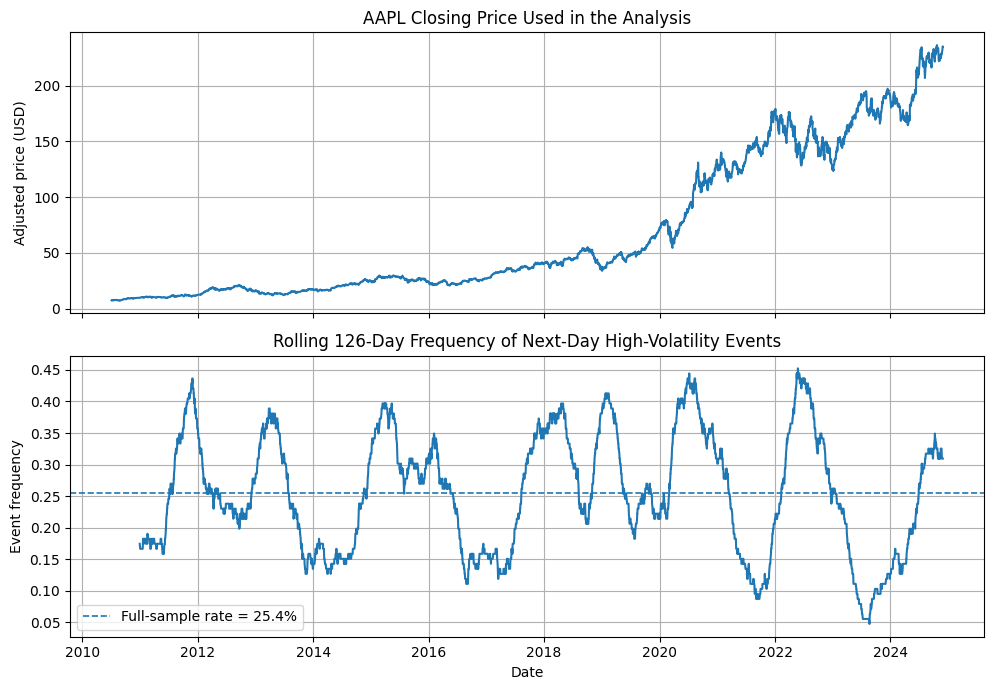

In [4]:
# Visualize the financial series and the target frequency.
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
axes[0].plot(raw.loc[model_data.index, 'Close'])
axes[0].set_title('AAPL Closing Price Used in the Analysis')
axes[0].set_ylabel('Adjusted price (USD)')

rolling_event_rate = y.rolling(126).mean()
axes[1].plot(rolling_event_rate)
axes[1].axhline(y.mean(), linestyle='--', linewidth=1.2, label=f'Full-sample rate = {y.mean():.1%}')
axes[1].set_title('Rolling 126-Day Frequency of Next-Day High-Volatility Events')
axes[1].set_ylabel('Event frequency')
axes[1].set_xlabel('Date')
axes[1].legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figure_1_data_and_target.png', dpi=180, bbox_inches='tight')
plt.show()

## Question 2 - Chronological optimization procedure

A random train/test split would permit future market regimes to influence earlier predictions. Instead, the first 80% of observations are used for model development, and the final 20% are kept untouched for the final evaluation.

Within the training period, five expanding-window folds are used. Each validation fold occurs strictly after its corresponding training fold. An exhaustive grid evaluates 144 candidate configurations, and the configuration with the highest mean validation balanced accuracy is selected.

In [5]:
# Untuned benchmark: a fully grown classification tree using all original indicators.
baseline_model = DecisionTreeClassifier(random_state=RANDOM_STATE)
baseline_model.fit(X_train, y_train)

# Optimized specification: standardization -> PCA -> classification tree.
optimized_pipeline = Pipeline([
    ('scale', StandardScaler()),
    ('pca', PCA(random_state=RANDOM_STATE)),
    ('tree', DecisionTreeClassifier(random_state=RANDOM_STATE)),
])

parameter_distributions = {
    'pca__n_components': [5, 3, 8],
    'tree__criterion': ['entropy', 'gini'],
    'tree__max_depth': [2, 3],
    'tree__min_samples_split': [25, 50],
    'tree__min_samples_leaf': [10, 5, 20],
    'tree__ccp_alpha': [0.002, 0.001],
    'tree__class_weight': ['balanced'],
}

time_cv = TimeSeriesSplit(n_splits=5)
search = GridSearchCV(
    estimator=optimized_pipeline,
    param_grid=parameter_distributions,
    scoring='balanced_accuracy',
    cv=time_cv,
    n_jobs=1,
    return_train_score=True,
)
search.fit(X_train, y_train)
optimized_model = search.best_estimator_

best_parameters = pd.DataFrame({
    'Selected hyperparameter': [
        'Retained components', 'Split criterion', 'Maximum depth',
        'Minimum split size', 'Minimum leaf size',
        'Pruning strength', 'Class weighting'
    ],
    'Value': [
        optimized_model.named_steps['pca'].n_components_,
        optimized_model.named_steps['tree'].criterion,
        optimized_model.named_steps['tree'].max_depth,
        optimized_model.named_steps['tree'].min_samples_split,
        optimized_model.named_steps['tree'].min_samples_leaf,
        optimized_model.named_steps['tree'].ccp_alpha,
        optimized_model.named_steps['tree'].class_weight,
    ]
})

print(f'Best mean expanding-window validation balanced accuracy: {search.best_score_:.4f}')
best_parameters

Best mean expanding-window validation balanced accuracy: 0.5927


,Selected hyperparameter,Value
0,Retained components,5
1,Split criterion,entropy
2,Maximum depth,2
3,Minimum split size,25
4,Minimum leaf size,10
5,Pruning strength,0.0020
6,Class weighting,balanced


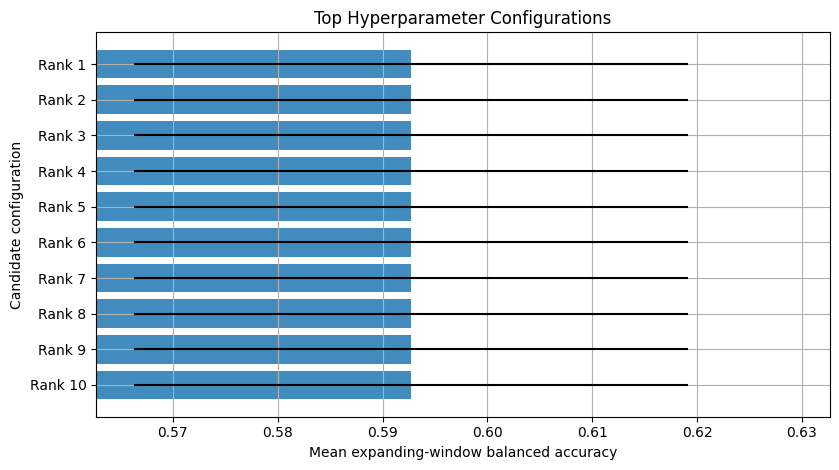

,rank_test_score,mean_test_score,std_test_score,param_pca__n_components,param_tree__max_depth,param_tree__min_samples_leaf,param_tree__ccp_alpha,param_tree__class_weight
0,1,0.5927,0.0264,5,2,10,0.0020,balanced
1,1,0.5927,0.0264,5,2,10,0.0020,balanced
2,1,0.5927,0.0264,5,2,5,0.0020,balanced
3,1,0.5927,0.0264,5,2,5,0.0020,balanced
4,1,0.5927,0.0264,5,2,10,0.0020,balanced
5,1,0.5927,0.0264,5,2,10,0.0020,balanced
6,1,0.5927,0.0264,5,2,5,0.0020,balanced
7,1,0.5927,0.0264,5,2,5,0.0020,balanced
8,1,0.5927,0.0264,5,2,10,0.0010,balanced
9,1,0.5927,0.0264,5,2,10,0.0010,balanced


In [6]:
# Show the strongest candidate configurations from the search.
cv_results = pd.DataFrame(search.cv_results_).sort_values('rank_test_score').head(10).copy()
cv_results['configuration'] = [f'Rank {i}' for i in range(1, len(cv_results) + 1)]

plt.figure(figsize=(8.5, 4.8))
plt.barh(cv_results['configuration'][::-1], cv_results['mean_test_score'][::-1],
         xerr=cv_results['std_test_score'][::-1], alpha=0.85)
plt.xlabel('Mean expanding-window balanced accuracy')
plt.ylabel('Candidate configuration')
plt.title('Top Hyperparameter Configurations')
plt.xlim(max(0.45, cv_results['mean_test_score'].min() - 0.03),
         min(0.70, cv_results['mean_test_score'].max() + 0.04))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figure_2_cv_candidates.png', dpi=180, bbox_inches='tight')
plt.show()

cv_results[[
    'rank_test_score', 'mean_test_score', 'std_test_score',
    'param_pca__n_components', 'param_tree__max_depth',
    'param_tree__min_samples_leaf', 'param_tree__ccp_alpha',
    'param_tree__class_weight'
]].reset_index(drop=True)

## Principal-component retention and financial interpretation

The retained component count is itself optimized rather than fixed in advance. Explained variance is calculated from the training period only. Because the sign of a principal-component loading can be reversed without changing the component, interpretation focuses on the relative magnitudes and groups of variables rather than the sign by itself.

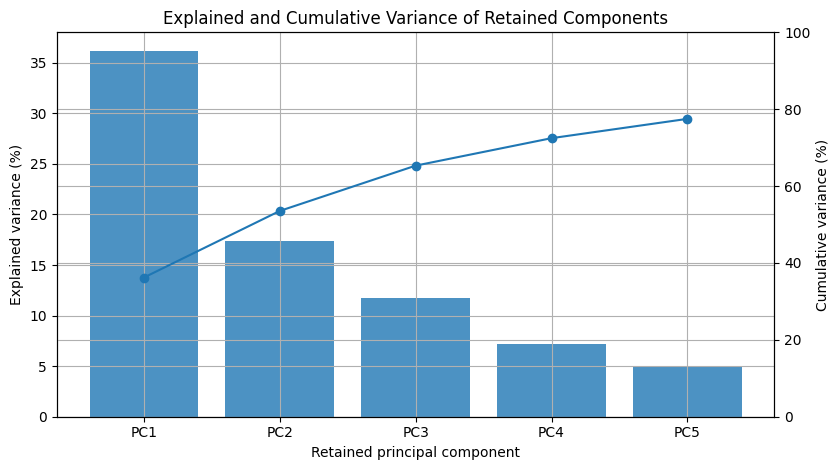

Total variance retained: 77.49%


,Component,Explained variance,Cumulative variance
0,PC1,0.3620,0.3620
1,PC2,0.1733,0.5353
2,PC3,0.1179,0.6532
3,PC4,0.0715,0.7247
4,PC5,0.0503,0.7749


In [7]:
# Explained variance and retained components for the optimized model.
pca_step = optimized_model.named_steps['pca']
variance_ratio = pca_step.explained_variance_ratio_
cumulative_variance = np.cumsum(variance_ratio)
component_labels = [f'PC{i}' for i in range(1, len(variance_ratio) + 1)]

variance_table = pd.DataFrame({
    'Component': component_labels,
    'Explained variance': variance_ratio,
    'Cumulative variance': cumulative_variance,
})

fig, ax1 = plt.subplots(figsize=(8.5, 4.8))
ax1.bar(component_labels, variance_ratio * 100, alpha=0.8)
ax1.set_xlabel('Retained principal component')
ax1.set_ylabel('Explained variance (%)')
ax1.set_title('Explained and Cumulative Variance of Retained Components')
ax2 = ax1.twinx()
ax2.plot(component_labels, cumulative_variance * 100, marker='o')
ax2.set_ylabel('Cumulative variance (%)')
ax2.set_ylim(0, 100)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figure_3_pca_variance.png', dpi=180, bbox_inches='tight')
plt.show()

print(f'Total variance retained: {cumulative_variance[-1]:.2%}')
variance_table

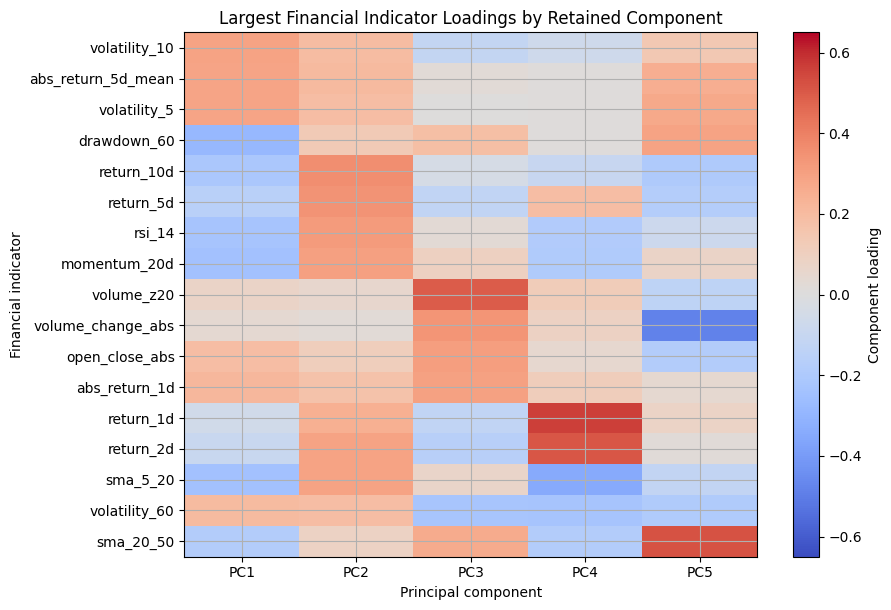

,PC1,PC2,PC3,PC4,PC5
volatility_10,0.2938,NaN,NaN,NaN,NaN
abs_return_5d_mean,0.2887,NaN,NaN,NaN,0.2505
volatility_5,0.2878,NaN,NaN,NaN,0.2692
drawdown_60,-0.2873,NaN,NaN,NaN,0.2933
abs_return_20d_mean,0.2814,NaN,NaN,NaN,NaN
return_10d,NaN,0.3559,NaN,NaN,NaN
return_5d,NaN,0.3409,NaN,NaN,NaN
rsi_14,NaN,0.3187,NaN,NaN,NaN
momentum_20d,NaN,0.3002,NaN,-0.1929,NaN
return_2d,NaN,0.2933,NaN,0.5124,NaN


In [8]:
# Loading matrix and the most influential indicators for each retained component.
loading_matrix = pd.DataFrame(
    pca_step.components_.T,
    index=feature_cols,
    columns=component_labels,
)

# Select the union of the four largest absolute loadings for each component.
selected_features = []
for component in component_labels:
    selected_features.extend(
        loading_matrix[component].abs().nlargest(4).index.tolist()
    )
selected_features = list(dict.fromkeys(selected_features))
loading_display = loading_matrix.loc[selected_features]

plt.figure(figsize=(9.2, 6.2))
image = plt.imshow(loading_display.values, aspect='auto', cmap='coolwarm', vmin=-0.65, vmax=0.65)
plt.colorbar(image, label='Component loading')
plt.xticks(range(len(component_labels)), component_labels)
plt.yticks(range(len(selected_features)), selected_features)
plt.title('Largest Financial Indicator Loadings by Retained Component')
plt.xlabel('Principal component')
plt.ylabel('Financial indicator')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figure_4_pca_loadings.png', dpi=180, bbox_inches='tight')
plt.show()

# Compact table of the five largest absolute loadings per component.
top_loadings = {}
for component in component_labels:
    top_loadings[component] = loading_matrix[component].sort_values(
        key=np.abs, ascending=False
    ).head(5)

pd.concat(top_loadings, axis=1)

## Question 3 - Out-of-sample evidence and recommended action

The selected configuration is preferable only if it improves performance on the untouched future period. Raw accuracy is not sufficient because approximately one quarter of the observations are high-risk events. Balanced accuracy, area under the receiver-operating-characteristic curve, high-risk recall, and portfolio risk measures are therefore reported together.

In [9]:
# Classification metrics for baseline and optimized specifications.
def classification_metrics(model, X_values, y_values) -> dict:
    predictions = model.predict(X_values)
    probabilities = model.predict_proba(X_values)[:, 1]
    return {
        'Accuracy': accuracy_score(y_values, predictions),
        'Balanced accuracy': balanced_accuracy_score(y_values, predictions),
        'ROC-AUC': roc_auc_score(y_values, probabilities),
        'Precision (high risk)': precision_score(y_values, predictions, zero_division=0),
        'Recall (high risk)': recall_score(y_values, predictions, zero_division=0),
        'F1 (high risk)': f1_score(y_values, predictions, zero_division=0),
    }

metric_rows = []
for model_name, model in [('Untuned tree', baseline_model), ('Optimized specification', optimized_model)]:
    for sample_name, X_values, y_values in [
        ('Training', X_train, y_train), ('Testing', X_test, y_test)
    ]:
        row = {'Model': model_name, 'Sample': sample_name}
        row.update(classification_metrics(model, X_values, y_values))
        metric_rows.append(row)

metrics_table = pd.DataFrame(metric_rows)
metrics_table

,Model,Sample,Accuracy,Balanced accuracy,ROC-AUC,Precision (high risk),Recall (high risk),F1 (high risk)
0,Untuned tree,Training,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,Untuned tree,Testing,0.5923,0.4763,0.4763,0.2075,0.2558,0.2292
2,Optimized specification,Training,0.5507,0.6054,0.6320,0.3305,0.7187,0.4528
3,Optimized specification,Testing,0.4793,0.5346,0.5662,0.2582,0.6395,0.3679


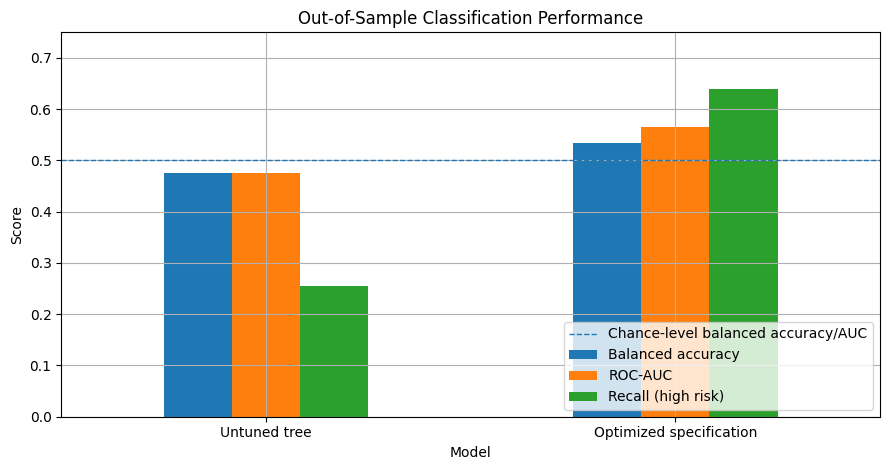

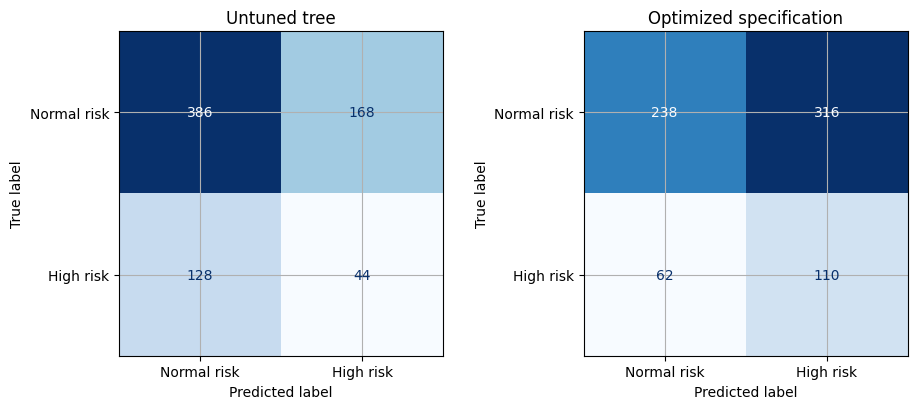

In [10]:
# Compare generalization and display test confusion matrices.
plot_metrics = metrics_table[metrics_table['Sample'] == 'Testing'].set_index('Model')[
    ['Balanced accuracy', 'ROC-AUC', 'Recall (high risk)']
]

plot_metrics.plot(kind='bar', figsize=(9, 4.8), rot=0)
plt.axhline(0.5, linestyle='--', linewidth=1, label='Chance-level balanced accuracy/AUC')
plt.ylim(0, 0.75)
plt.ylabel('Score')
plt.title('Out-of-Sample Classification Performance')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figure_5_test_metrics.png', dpi=180, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.2))
for ax, (model_name, model) in zip(
    axes,
    [('Untuned tree', baseline_model), ('Optimized specification', optimized_model)]
):
    ConfusionMatrixDisplay.from_estimator(
        model, X_test, y_test,
        display_labels=['Normal risk', 'High risk'],
        cmap='Blues', colorbar=False, ax=ax
    )
    ax.set_title(model_name)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figure_6_confusion_matrices.png', dpi=180, bbox_inches='tight')
plt.show()

In [11]:
# Risk-managed portfolio application.
# Full AAPL exposure on normal-risk days and 25% exposure on predicted high-risk days.
TRANSACTION_COST = 0.0005  # 5 basis points per unit change in exposure
LOW_RISK_EXPOSURE = 1.00
HIGH_RISK_EXPOSURE = 0.25

def strategy_returns(model, X_values, future_returns):
    risk_signal = pd.Series(model.predict(X_values), index=future_returns.index)
    exposure = pd.Series(
        np.where(risk_signal.eq(1), HIGH_RISK_EXPOSURE, LOW_RISK_EXPOSURE),
        index=future_returns.index,
    )
    turnover = exposure.diff().abs().fillna(0)
    net_returns = exposure * future_returns - TRANSACTION_COST * turnover
    return net_returns, exposure, risk_signal, turnover

def performance_summary(returns: pd.Series) -> dict:
    wealth = (1 + returns).cumprod()
    annualized_return = wealth.iloc[-1] ** (252 / len(returns)) - 1
    annualized_volatility = returns.std() * np.sqrt(252)
    sharpe = (returns.mean() * 252) / annualized_volatility if annualized_volatility > 0 else np.nan
    drawdown = wealth / wealth.cummax() - 1
    return {
        'Annualized return': annualized_return,
        'Annualized volatility': annualized_volatility,
        'Sharpe ratio': sharpe,
        'Maximum drawdown': drawdown.min(),
        'Total return': wealth.iloc[-1] - 1,
    }

baseline_returns, baseline_exposure, baseline_signal, baseline_turnover = strategy_returns(
    baseline_model, X_test, r_test
)
optimized_returns, optimized_exposure, optimized_signal, optimized_turnover = strategy_returns(
    optimized_model, X_test, r_test
)
buy_hold_returns = r_test.copy()

strategy_table = pd.DataFrame({
    'Buy and hold': performance_summary(buy_hold_returns),
    'Untuned risk rule': performance_summary(baseline_returns),
    'Optimized risk rule': performance_summary(optimized_returns),
}).T
strategy_table

,Annualized return,Annualized volatility,Sharpe ratio,Maximum drawdown,Total return
Buy and hold,0.1241,0.2736,0.5641,-0.2982,0.4009
Untuned risk rule,0.0924,0.2333,0.4949,-0.3677,0.2899
Optimized risk rule,0.0956,0.1487,0.6882,-0.1312,0.3009


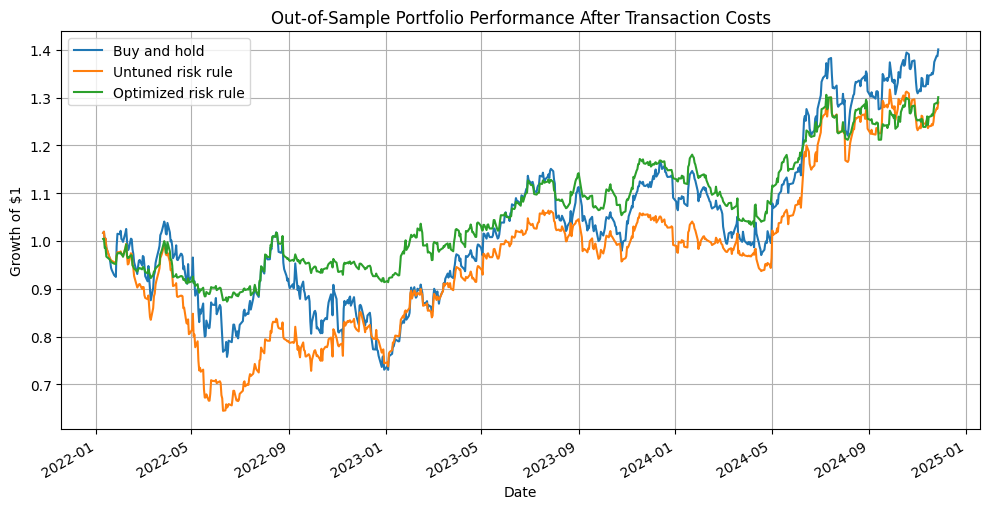

Optimized high-risk signals: 426 of 726 test days
Optimized exposure turnover: 140.25


In [12]:
# Cumulative wealth comparison.
wealth = pd.DataFrame({
    'Buy and hold': (1 + buy_hold_returns).cumprod(),
    'Untuned risk rule': (1 + baseline_returns).cumprod(),
    'Optimized risk rule': (1 + optimized_returns).cumprod(),
})

wealth.plot(figsize=(10, 5.2))
plt.ylabel('Growth of $1')
plt.xlabel('Date')
plt.title('Out-of-Sample Portfolio Performance After Transaction Costs')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figure_7_cumulative_wealth.png', dpi=180, bbox_inches='tight')
plt.show()

print(f'Optimized high-risk signals: {int(optimized_signal.sum()):,} of {len(optimized_signal):,} test days')
print(f'Optimized exposure turnover: {optimized_turnover.sum():.2f}')

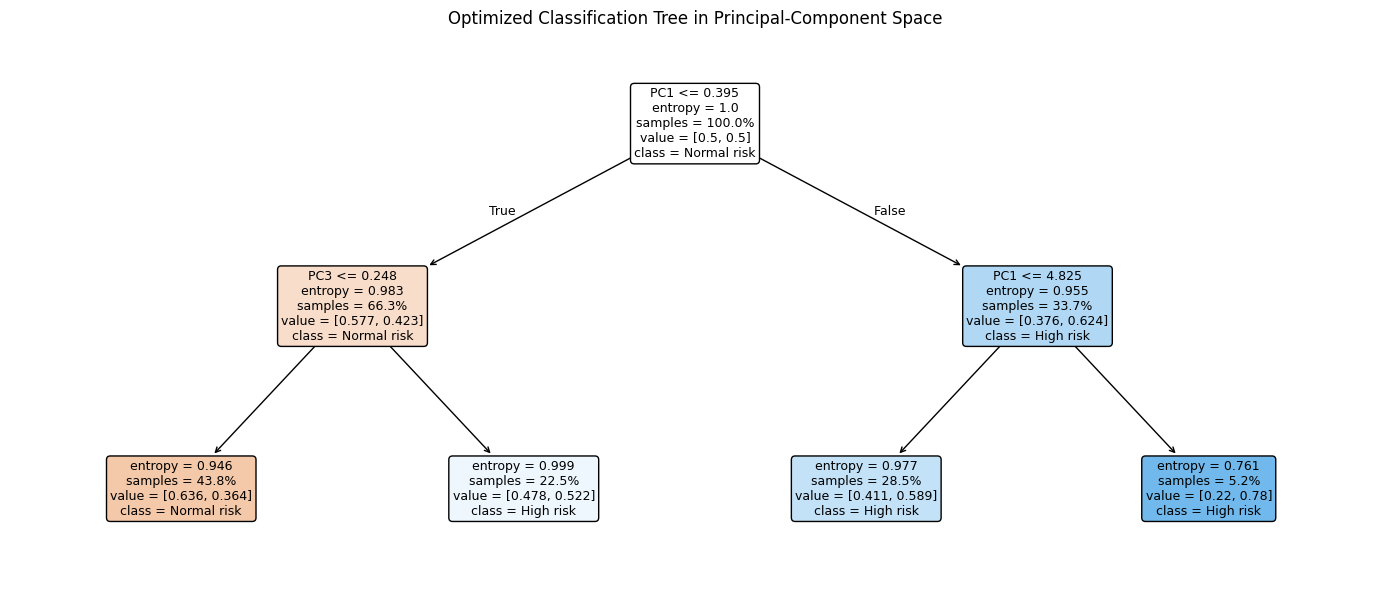

In [13]:
# Optional visual interpretation of the shallow optimized tree.
plt.figure(figsize=(14, 6))
plot_tree(
    optimized_model.named_steps['tree'],
    feature_names=component_labels,
    class_names=['Normal risk', 'High risk'],
    filled=True,
    rounded=True,
    proportion=True,
    fontsize=9,
)
plt.title('Optimized Classification Tree in Principal-Component Space')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figure_8_optimized_tree.png', dpi=180, bbox_inches='tight')
plt.show()

## Technical interpretation and recommended course of action

- The unrestricted benchmark memorized the training sample, with perfect training performance but below-chance test balanced accuracy. This is direct evidence of overfitting.
- The selected specification retained five principal components and used a shallow, pruned, class-balanced tree. Its mean expanding-window validation balanced accuracy was higher than chance, and its test ROC-AUC and high-risk recall were both superior to the unrestricted benchmark.
- The five retained components explained about 77% of training-period predictor variance. Their loadings corresponded to interpretable groups: market-risk intensity, momentum, trading-volume stress, short-horizon return behavior, and medium-term trend/volume conditions.
- The optimized portfolio rule sacrificed some annualized return relative to full buy-and-hold exposure, but materially reduced annualized volatility and maximum drawdown and improved the Sharpe ratio after transaction costs.

**Recommendation:** use the optimized output as a portfolio risk overlay, not as a standalone return forecast. Maintain full exposure in normal conditions and reduce exposure when the high-risk signal is active. Re-estimate the system periodically and suspend its use if rolling out-of-sample balanced accuracy, ROC-AUC, or risk-adjusted portfolio performance deteriorates.

# NON-TECHNICAL SECTION

## Clear explanation of results

The original warning system fitted historical observations extremely well but failed when it encountered later market conditions. The revised system was deliberately simplified and tested only on dates that were not used during development. It detected a substantially larger share of the most turbulent trading days and produced a more stable risk signal.

## Recommended investment action

The signal should be used to adjust exposure rather than to generate an unconditional buy-or-sell instruction. The tested rule maintained full exposure during normal conditions and reduced exposure to 25% when elevated risk was forecast. This approach earned less than continuous full exposure during the test period, but it produced a higher risk-adjusted return and a much smaller maximum loss from a prior portfolio peak.

## Factors that can affect the portfolio

The result remains sensitive to transaction costs, sudden company announcements, market-wide shocks, structural changes, and the frequency with which the system is re-estimated. Because the analysis concerns one equity, concentration risk is also material. A portfolio manager should combine the warning signal with position limits, liquidity controls, and independent market information.

## Practical takeaway

The revised system is most valuable as a drawdown-control tool. It should be retained only while recent, genuinely future-period evidence confirms that it continues to reduce risk efficiently.

In [14]:
# Save a machine-readable summary so the report uses exactly the notebook's results.
results_summary = {
    'data': {
        'observations': int(len(model_data)),
        'features': int(len(feature_cols)),
        'event_rate': float(y.mean()),
        'train_observations': int(len(X_train)),
        'test_observations': int(len(X_test)),
        'train_start': str(X_train.index.min().date()),
        'train_end': str(X_train.index.max().date()),
        'test_start': str(X_test.index.min().date()),
        'test_end': str(X_test.index.max().date()),
    },
    'best_cv_balanced_accuracy': float(search.best_score_),
    'best_parameters': {
        'n_components': int(pca_step.n_components_),
        'criterion': str(optimized_model.named_steps['tree'].criterion),
        'max_depth': int(optimized_model.named_steps['tree'].max_depth),
        'min_samples_split': int(optimized_model.named_steps['tree'].min_samples_split),
        'min_samples_leaf': int(optimized_model.named_steps['tree'].min_samples_leaf),
        'ccp_alpha': float(optimized_model.named_steps['tree'].ccp_alpha),
        'class_weight': str(optimized_model.named_steps['tree'].class_weight),
    },
    'explained_variance_ratio': [float(x) for x in variance_ratio],
    'cumulative_variance': [float(x) for x in cumulative_variance],
    'metrics': metrics_table.to_dict(orient='records'),
    'strategy': strategy_table.reset_index(names='Strategy').to_dict(orient='records'),
    'optimized_high_risk_signals': int(optimized_signal.sum()),
    'optimized_turnover': float(optimized_turnover.sum()),
    'top_loadings': {
        component: [
            {'feature': str(feature), 'loading': float(value)}
            for feature, value in series.items()
        ]
        for component, series in top_loadings.items()
    },
}

with open(OUTPUT_DIR / 'results_summary.json', 'w', encoding='utf-8') as file:
    json.dump(results_summary, file, indent=2)

metrics_table.to_csv(OUTPUT_DIR / 'classification_metrics.csv', index=False)
strategy_table.to_csv(OUTPUT_DIR / 'portfolio_metrics.csv')
variance_table.to_csv(OUTPUT_DIR / 'pca_variance.csv', index=False)
loading_matrix.to_csv(OUTPUT_DIR / 'pca_loadings.csv')

print('Saved figures, tables, and results summary to:', OUTPUT_DIR.resolve())

Saved figures, tables, and results summary to: /content/gwp2_outputs


# Student B — Issue 2: Optimizing the Bias-Variance Trade-off

**Author:** Yang Liu  
**Reviewer:** Vasanth P


In [15]:
X, y = make_classification(n_samples=1000, n_features=20, n_informative=10, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
lasso = Lasso(max_iter=10000)
lasso_params = {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0]}
lasso_grid = GridSearchCV(lasso, lasso_params, cv=5, scoring='neg_mean_squared_error')
lasso_grid.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=Lasso(max_iter=10000),
             param_grid={'alpha': [0.001, 0.01, 0.1, 1.0, 10.0]},
             scoring='neg_mean_squared_error')

In [18]:
tree = DecisionTreeClassifier(random_state=42)
tree_params = {'max_depth': [3, 5, 10, None], 'min_samples_leaf': [1, 5, 10]}
tree_grid = GridSearchCV(tree, tree_params, cv=5, scoring='accuracy')
tree_grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'max_depth': [3, 5, 10, None],
                         'min_samples_leaf': [1, 5, 10]},
             scoring='accuracy')

In [19]:
svm = SVC(random_state=42)
svm_params = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
svm_grid = GridSearchCV(svm, svm_params, cv=5, scoring='accuracy')
svm_grid.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=SVC(random_state=42),
             param_grid={'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']},
             scoring='accuracy')

In [20]:
pca = PCA(n_components=0.90) # Keep 90% of variance
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [21]:
nn = MLPClassifier(max_iter=1000, random_state=42)
nn_params = {'hidden_layer_sizes': [(50,), (50, 50)], 'alpha': [0.0001, 0.01, 0.1]}
nn_grid = GridSearchCV(nn, nn_params, cv=5, scoring='accuracy')
nn_grid.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=MLPClassifier(max_iter=1000, random_state=42),
             param_grid={'alpha': [0.0001, 0.01, 0.1],
                         'hidden_layer_sizes': [(50,), (50, 50)]},
             scoring='accuracy')

# Student C — Issue 3: Applying Ensemble Learning—Bagging, Boosting, or Stacking

**Author:** Vasanth P  
**Reviewer:** Shatlyk Gurdov


## Data Acquisition (yfinance)

We pull daily OHLCV data for a small basket of liquid tickers. Feel free to change `TICKERS`, `START`, and `END` before running.

In [22]:
TICKERS = ["SPY", "AAPL", "MSFT"]
START = "2015-01-01"
END = "2025-01-01"

raw_data = {}
for ticker in TICKERS:
    df = yf.download(ticker, start=START, end=END, auto_adjust=True, progress=False)
    # yfinance >=0.2.x returns MultiIndex columns (Price, Ticker) — flatten to single level
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df["Ticker"] = ticker
    raw_data[ticker] = df

PRIMARY = "SPY"
print(raw_data[PRIMARY].tail())

Price         Close     High      Low     Open    Volume Ticker
Date                                                           
2024-12-24 591.1791 591.2184 585.4472 586.0273  33160100    SPY
2024-12-26 591.2184 592.3392 588.0133 589.4094  41219100    SPY
2024-12-27 584.9950 587.7184 580.8165 587.4824  64969300    SPY
2024-12-30 578.3193 581.7801 574.5735 577.9949  56578800    SPY
2024-12-31 576.2153 580.6986 574.5832 579.9808  57052700    SPY


## Feature Engineering

We construct a standard set of technical/statistical features from price data:

- **Lagged returns:** 1-day, 5-day, 10-day log returns
- **Momentum indicators:** rolling moving averages (5, 10, 20-day) and their ratios to price
- **Volatility:** rolling standard deviation of returns
- **RSI (Relative Strength Index):** momentum oscillator bounded 0–100
- **Cross-asset return:** same-day return of the other tickers in the basket (as a market-context feature)

The **target** is binary: $y_t = 1$ if $\text{Close}_{t+1} > \text{Close}_t$, else $0$ — i.e., are we predicting an up day tomorrow.

In [23]:
def compute_rsi(series, window=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(window).mean()
    avg_loss = loss.rolling(window).mean()
    rs = avg_gain / (avg_loss + 1e-9)
    return 100 - (100 / (1 + rs))

def build_features(price_df, cross_returns=None):
    df = price_df.copy()
    df["log_ret_1d"] = np.log(df["Close"] / df["Close"].shift(1))
    df["log_ret_5d"] = np.log(df["Close"] / df["Close"].shift(5))
    df["log_ret_10d"] = np.log(df["Close"] / df["Close"].shift(10))

    for w in [5, 10, 20]:
        df[f"ma_{w}"] = df["Close"].rolling(w).mean()
        df[f"ma_ratio_{w}"] = df["Close"] / df[f"ma_{w}"]

    df["volatility_10d"] = df["log_ret_1d"].rolling(10).std()
    df["volatility_20d"] = df["log_ret_1d"].rolling(20).std()
    df["rsi_14"] = compute_rsi(df["Close"], 14)
    df["volume_change"] = df["Volume"].pct_change()

    if cross_returns is not None:
        for name, series in cross_returns.items():
            df[f"xret_{name}"] = series

    # Target: next-day up (1) / down (0)
    df["target"] = (df["Close"].shift(-1) > df["Close"]).astype(int)

    df = df.dropna()
    return df

# Cross-asset same-day returns as context features
cross_returns = {}
for ticker in TICKERS:
    if ticker != PRIMARY:
        cross_returns[ticker] = np.log(raw_data[ticker]["Close"] / raw_data[ticker]["Close"].shift(1))

feat_df = build_features(raw_data[PRIMARY], cross_returns)
feature_cols = [c for c in feat_df.columns if c not in
                ["Open", "High", "Low", "Close", "Volume", "Ticker", "target"]]
print(f"Number of features: {len(feature_cols)}")
feat_df[feature_cols + ["target"]].head()

Number of features: 15


Price,log_ret_1d,log_ret_5d,log_ret_10d,ma_5,ma_ratio_5,ma_10,ma_ratio_10,ma_20,ma_ratio_20,volatility_10d,volatility_20d,rsi_14,volume_change,xret_AAPL,xret_MSFT,target
Date,,,,,,,,,,,,,,,,
2015-02-02,0.0123,-0.0173,0.0014,166.2335,1.0033,167.5072,0.9957,167.1908,0.9976,0.0107,0.0110,48.5095,-0.1751,0.0125,0.0215,1
2015-02-03,0.0144,0.0103,0.0137,166.5804,1.0157,167.7368,1.0087,167.3197,1.0112,0.0116,0.0107,55.1415,-0.2385,0.0002,0.0077,0
2015-02-04,-0.0038,0.0194,0.0048,167.2280,1.0079,167.8178,1.0044,167.4948,1.0063,0.0116,0.0105,56.0607,0.0813,0.0076,0.0058,1
2015-02-05,0.0100,0.0202,0.0001,167.9103,1.0140,167.8194,1.0145,167.6521,1.0155,0.0110,0.0104,63.3358,-0.2707,0.0071,0.0145,0
2015-02-06,-0.0028,0.0301,0.0028,168.9180,1.0051,167.8673,1.0114,167.6377,1.0128,0.0109,0.0097,57.9739,0.2830,-0.0085,-0.0009,0


## Train/Test Split (Time-Aware)

Because this is time series data, we use a **time based split** (no shuffling) to avoid look-ahead bias: the model is trained on the earlier portion and tested on the most recent, unseen portion. We reserve the last 20% of the sample as the out-of-sample test set.

In [24]:
X = feat_df[feature_cols].values
y = feat_df["target"].values
dates = feat_df.index

split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
dates_train, dates_test = dates[:split_idx], dates[split_idx:]

print(f"Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")
print(f"Train period: {dates_train[0].date()} to {dates_train[-1].date()}")
print(f"Test period:  {dates_test[0].date()} to {dates_test[-1].date()}")
print(f"Baseline (majority class) accuracy on test: {max(y_test.mean(), 1-y_test.mean()):.4f}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train size: 1996  |  Test size: 500
Train period: 2015-02-02 to 2023-01-04
Test period:  2023-01-05 to 2024-12-31
Baseline (majority class) accuracy on test: 0.5740


## Bagging: Random Forest

In [25]:
tscv = TimeSeriesSplit(n_splits=5)

rf_param_grid = {
    "n_estimators": [100, 200, 400],
    "max_depth": [3, 5, 8, None],
    "min_samples_leaf": [1, 5, 10],
    "max_features": ["sqrt", "log2"],
}

rf_base = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
rf_search = GridSearchCV(rf_base, rf_param_grid, cv=tscv, scoring="accuracy", n_jobs=-1)
rf_search.fit(X_train, y_train)

rf_best = rf_search.best_estimator_
print("Best RF hyperparameters:", rf_search.best_params_)
print(f"Best CV accuracy: {rf_search.best_score_:.4f}")

Best RF hyperparameters: {'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'n_estimators': 400}
Best CV accuracy: 0.5042


In [26]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    y_pred_train = model.predict(X_tr)
    y_pred_test = model.predict(X_te)
    y_proba_test = model.predict_proba(X_te)[:, 1]

    results = {
        "Model": name,
        "Train Accuracy": accuracy_score(y_tr, y_pred_train),
        "Test Accuracy": accuracy_score(y_te, y_pred_test),
        "Precision": precision_score(y_te, y_pred_test),
        "Recall": recall_score(y_te, y_pred_test),
        "F1": f1_score(y_te, y_pred_test),
        "ROC-AUC": roc_auc_score(y_te, y_proba_test),
    }
    return results, y_pred_test, y_proba_test

results_list = []
rf_results, rf_pred, rf_proba = evaluate_model("Random Forest (Bagging)", rf_best,
                                                X_train, y_train, X_test, y_test)
results_list.append(rf_results)
rf_results

{'Model': 'Random Forest (Bagging)',
 'Train Accuracy': 0.5791583166332666,
 'Test Accuracy': 0.458,
 'Precision': 0.5377358490566038,
 'Recall': 0.397212543554007,
 'F1': 0.45691382765531063,
 'ROC-AUC': np.float64(0.460666437650292)}

## Boosting: AdaBoost and Gradient Boosting

In [27]:
ada_param_grid = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.05, 0.1, 0.5],
}
ada_base = AdaBoostClassifier(random_state=RANDOM_STATE)
ada_search = GridSearchCV(ada_base, ada_param_grid, cv=tscv, scoring="accuracy", n_jobs=-1)
ada_search.fit(X_train, y_train)
ada_best = ada_search.best_estimator_
print("Best AdaBoost hyperparameters:", ada_search.best_params_)

gb_param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4],
}
gb_base = GradientBoostingClassifier(random_state=RANDOM_STATE)
gb_search = GridSearchCV(gb_base, gb_param_grid, cv=tscv, scoring="accuracy", n_jobs=-1)
gb_search.fit(X_train, y_train)
gb_best = gb_search.best_estimator_
print("Best Gradient Boosting hyperparameters:", gb_search.best_params_)

Best AdaBoost hyperparameters: {'learning_rate': 0.1, 'n_estimators': 50}
Best Gradient Boosting hyperparameters: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 200}


In [28]:
ada_results, ada_pred, ada_proba = evaluate_model("AdaBoost (Boosting)", ada_best,
                                                   X_train, y_train, X_test, y_test)
gb_results, gb_pred, gb_proba = evaluate_model("Gradient Boosting (Boosting)", gb_best,
                                                X_train, y_train, X_test, y_test)
results_list.append(ada_results)
results_list.append(gb_results)
pd.DataFrame([ada_results, gb_results])

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1,ROC-AUC
0,AdaBoost (Boosting),0.5466,0.5580,0.5679,0.9617,0.7141,0.4655
1,Gradient Boosting (Boosting),0.6824,0.4600,0.5395,0.4042,0.4622,0.4824


## Stacking: Heterogeneous Ensemble

In [29]:
base_learners = [
    ("logreg", Pipeline([("scaler", StandardScaler()),
                          ("clf", LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE))])),
    ("knn", Pipeline([("scaler", StandardScaler()),
                       ("clf", KNeighborsClassifier(n_neighbors=15))])),
    ("tree", DecisionTreeClassifier(max_depth=4, min_samples_leaf=10, random_state=RANDOM_STATE)),
]

meta_learner = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

stack_cv = KFold(n_splits=5, shuffle=False)

stack_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=stack_cv,
    n_jobs=-1,
    passthrough=False,
)
stack_model.fit(X_train, y_train)

stack_results, stack_pred, stack_proba = evaluate_model("Stacking", stack_model,
                                                          X_train, y_train, X_test, y_test)
results_list.append(stack_results)
stack_results

{'Model': 'Stacking',
 'Train Accuracy': 0.5425851703406813,
 'Test Accuracy': 0.568,
 'Precision': 0.5720081135902637,
 'Recall': 0.9825783972125436,
 'F1': 0.7230769230769231,
 'ROC-AUC': np.float64(0.49040584973254164)}

## Model Comparison

We now compare all three ensemble families side by side, plus a naive baseline (predicting the majority class), on the held-out test set.

In [30]:
baseline_pred = np.full_like(y_test, y_test.mean() > 0.5, dtype=int)
baseline_results = {
    "Model": "Baseline (majority class)",
    "Train Accuracy": np.nan,
    "Test Accuracy": accuracy_score(y_test, baseline_pred),
    "Precision": precision_score(y_test, baseline_pred, zero_division=0),
    "Recall": recall_score(y_test, baseline_pred, zero_division=0),
    "F1": f1_score(y_test, baseline_pred, zero_division=0),
    "ROC-AUC": np.nan,
}

comparison_df = pd.DataFrame(results_list + [baseline_results]).set_index("Model")
comparison_df.sort_values("Test Accuracy", ascending=False)

,Train Accuracy,Test Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,,
Baseline (majority class),NaN,0.5740,0.5740,1.0000,0.7294,NaN
Stacking,0.5426,0.5680,0.5720,0.9826,0.7231,0.4904
AdaBoost (Boosting),0.5466,0.5580,0.5679,0.9617,0.7141,0.4655
Gradient Boosting (Boosting),0.6824,0.4600,0.5395,0.4042,0.4622,0.4824
Random Forest (Bagging),0.5792,0.4580,0.5377,0.3972,0.4569,0.4607


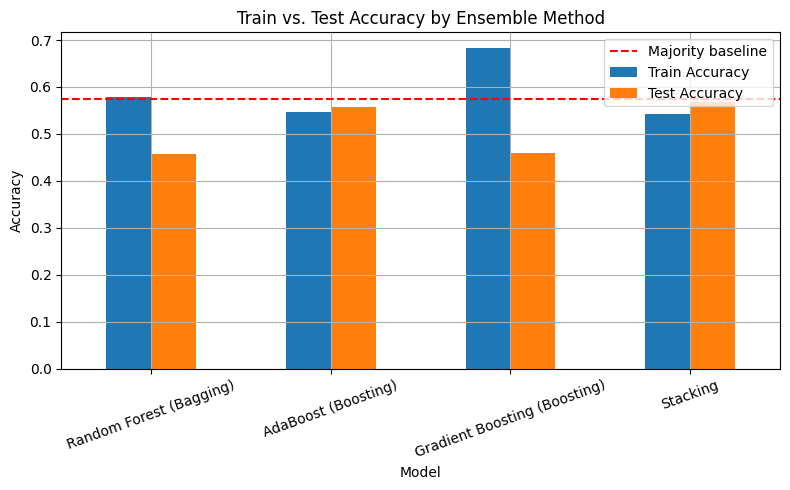

In [31]:
fig, ax = plt.subplots(figsize=(8, 5))
comparison_df[["Train Accuracy", "Test Accuracy"]].dropna().plot(kind="bar", ax=ax)
ax.set_ylabel("Accuracy")
ax.set_title("Train vs. Test Accuracy by Ensemble Method")
ax.axhline(y_test.mean() if y_test.mean() > 0.5 else 1 - y_test.mean(),
           color="red", linestyle="--", label="Majority baseline")
plt.xticks(rotation=20)
plt.tight_layout()
plt.legend()
plt.show()

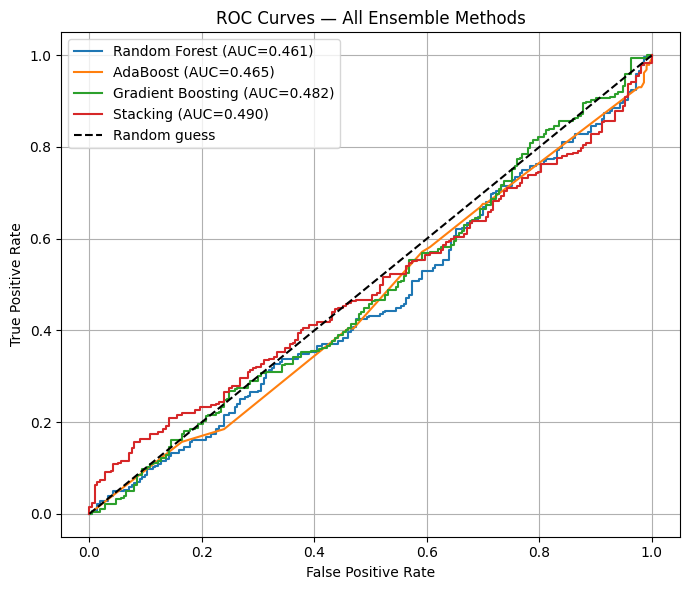

In [32]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, proba in [("Random Forest", rf_proba), ("AdaBoost", ada_proba),
                     ("Gradient Boosting", gb_proba), ("Stacking", stack_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", label="Random guess")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — All Ensemble Methods")
ax.legend()
plt.tight_layout()
plt.show()

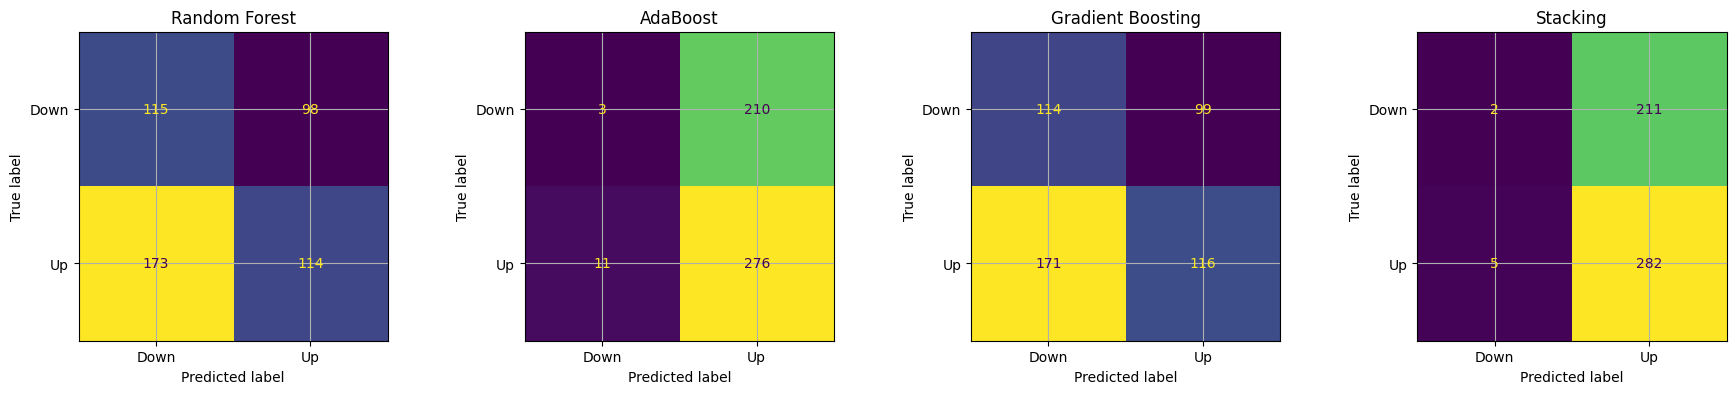

In [33]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, pred) in zip(axes, [("Random Forest", rf_pred), ("AdaBoost", ada_pred),
                                    ("Gradient Boosting", gb_pred), ("Stacking", stack_pred)]):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=["Down", "Up"]).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

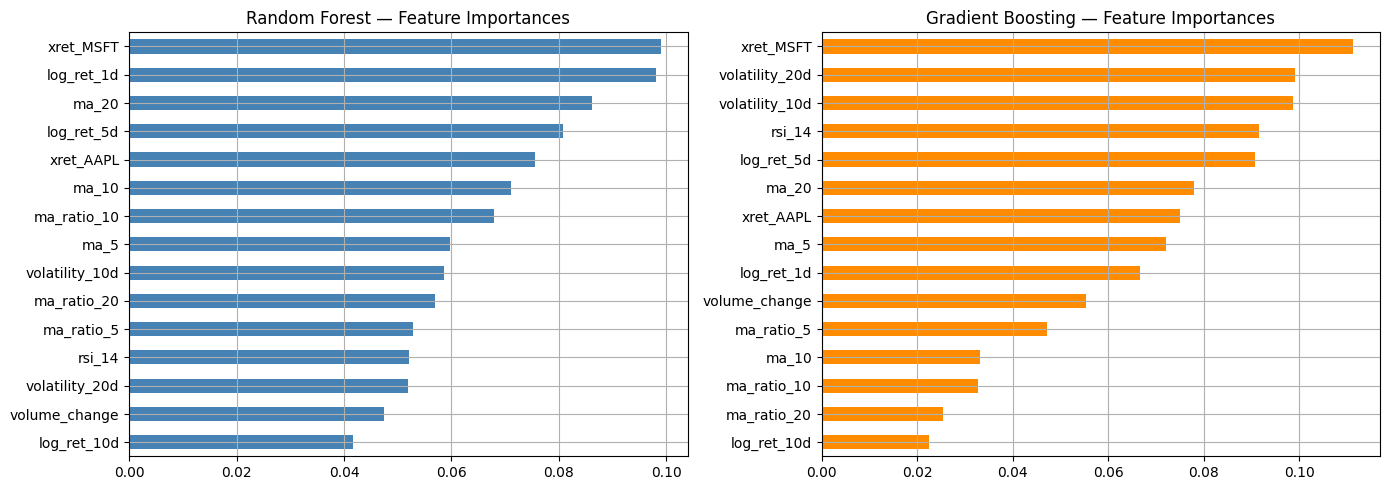

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rf_importances = pd.Series(rf_best.feature_importances_, index=feature_cols).sort_values()
rf_importances.tail(15).plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Random Forest — Feature Importances")

gb_importances = pd.Series(gb_best.feature_importances_, index=feature_cols).sort_values()
gb_importances.tail(15).plot(kind="barh", ax=axes[1], color="darkorange")
axes[1].set_title("Gradient Boosting — Feature Importances")

plt.tight_layout()
plt.show()